# Monte Carlo Portfolio Projections

This notebook demonstrates forward-looking portfolio projections using Monte Carlo simulation.

Included:
1. Estimate mean and covariance of historical returns
2. Simulate many future portfolio return paths
3. Compute distribution of terminal portfolio values
4. Visualize scenario outcomes (median, best-case, worst-case)

This is an extension of Monte Carlo VaR, shifting from single-day risk to **multi-period scenario analysis**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from src.portfolio import simulate_portfolio_paths

## Load Data
Using the same 4-asset portfolio (SPY, BND, GLD, QQQ).

In [2]:
tickers = ["SPY", "BND", "GLD", "QQQ"]
data = pd.read_csv(
    "../data/sample_prices.csv",
    index_col=0,
    parse_dates=[0],
    date_parser=lambda x: pd.to_datetime(x, format="%d/%m/%Y")
)
log_returns = np.log(data / data.shift(1)).dropna()

weights = np.array([0.25, 0.25, 0.25, 0.25])
portfolio_value = 1_000_000

## Simulate Portfolio Paths
Simulating 10,000 future paths, each of length 60 trading days ~3 months.

In [8]:
horizon = 60  # days
sims = 10_000

paths = simulate_portfolio_paths(log_returns, weights, horizon=horizon, sims=sims, seed=42)
terminal_returns = paths.sum(axis=1)
terminal_values = portfolio_value * (1 + terminal_returns)

terminal_values[:10]

array([1058746.05977635,  977146.77661627, 1119425.69112107,
        982939.46481756,  884571.08765277, 1042270.74082072,
        900828.69994453, 1088860.6228303 ,  992672.2930048 ,
       1065334.66651998])

## Distribution of Terminal Portfolio Values

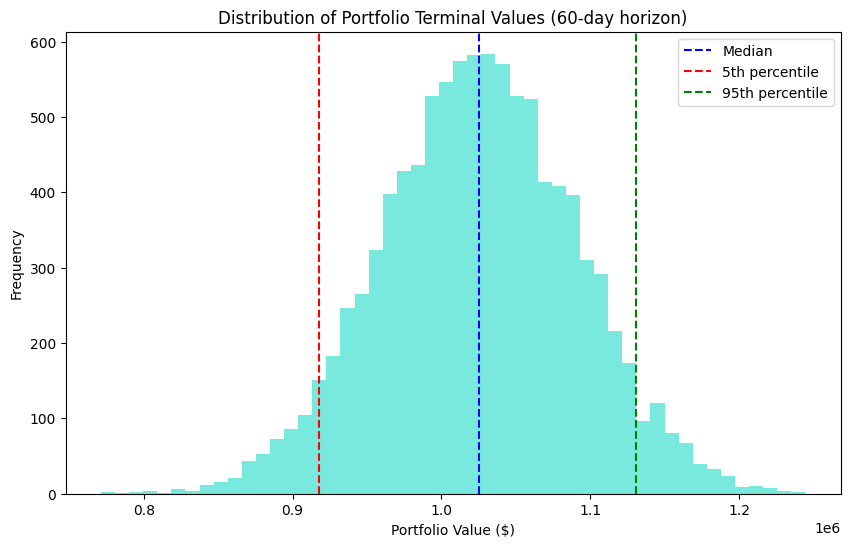

In [9]:
plt.figure(figsize=(10,6))
plt.hist(terminal_values, bins=50, alpha=0.7, color="turquoise")
plt.axvline(np.median(terminal_values), color="blue", linestyle="--", label="Median")
plt.axvline(np.percentile(terminal_values, 5), color="red", linestyle="--", label="5th percentile")
plt.axvline(np.percentile(terminal_values, 95), color="green", linestyle="--", label="95th percentile")
plt.title("Distribution of Portfolio Terminal Values (60-day horizon)")
plt.xlabel("Portfolio Value ($)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Example Path Visualization
We plot a few simulated portfolio return paths to show possible scenarios.

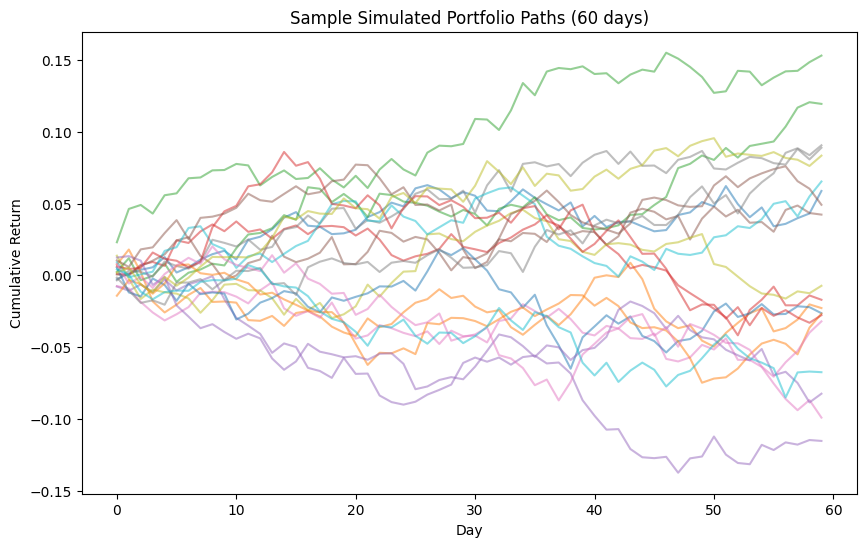

In [7]:
plt.figure(figsize=(10,6))
for i in range(20):  # plot 20 sample paths
    plt.plot(np.cumsum(paths[i]), alpha=0.5)
plt.title("Sample Simulated Portfolio Paths (60 days)")
plt.xlabel("Day")
plt.ylabel("Cumulative Return")
plt.show()

## Summary
- Monte Carlo projections allow visualisation of the distribution of outcomes over time.
- Median, 5th, and 95th percentiles provide a quick risk/return picture.
- This framework can be extended to stress testing, longer horizons, and non-Normal distributions.

This notebook closes the series by shifting from single-day VaR to multi-period scenario analysis, to demonstrate how quant risk tools can extend into portfolio management.